In [1]:
!git clone https://github.com/HoangHumg1210/hoankiem-air-quality-.git
%cd hoankiem-air-quality-


Cloning into 'hoankiem-air-quality-'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (37/37), done.
Receiving objects: 100% (54/54), 7.66 MiB | 5.21 MiB/s, done.
remote: Total 54 (delta 14), reused 50 (delta 10), pack-reused 0 (from 0)
Resolving deltas: 100% (14/14), done.
/content/hoankiem-air-quality-


In [2]:
# import os, sys

# PROJECT_ROOT = "/content/hoankiem-air-quality"  # thư mục chứa folder src/
# assert os.path.isdir(PROJECT_ROOT), f"Không thấy thư mục: {PROJECT_ROOT}"

# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)  # ưu tiên path này

In [16]:
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




In [4]:
from src.data_utils import (
    set_seed,
    load_and_clean_data,
    add_time_features,
    add_target_features,
    split_data,
    transform_target,
    preprocess_features,
    create_sequences
)

In [5]:
TARGET = 'PM25'
LOOKBACK = 336
HORIZON = 8
USE_LOG_TARGET = True
DATA_PATH = 'data/processed/data2225_done.csv'


In [6]:
set_seed()
df = load_and_clean_data(DATA_PATH)
df.head()

/content/hoankiem-air-quality-/src/data_utils.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)


,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,HolidayName,IsHoliday,Accumulated Hours of Rain
Local Time,,,,,,,,,,,,,,,,
2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100.0,0.00,1020.0,95.0,15.5,0.6,2.00,Ngày thường,0,0.0
2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91.0,0.00,1021.0,94.0,15.4,0.7,2.33,Ngày thường,0,0.0
2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83.0,0.50,1022.0,93.0,15.3,1.0,2.66,Ngày thường,0,1.0
2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75.0,0.75,1022.0,93.0,15.2,1.5,3.00,Ngày thường,0,2.0
2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83.0,0.00,1021.0,87.0,15.6,1.9,3.00,Ngày thường,0,0.0


In [7]:
# 2 feature engineering
df = add_time_features(df)
df = add_target_features(df)

# 3 split time-series
train_df, val_df, test_df = split_data(df)


In [8]:

# 4 transform target
y_train, y_val, y_test, scaler_y, inverse_target_transform = transform_target(
    train_df, val_df, test_df
)

# 5 preprocess features
X_train, X_val, X_test, preprocess = preprocess_features(
    train_df, val_df, test_df
)

# 6 create sequences
X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)


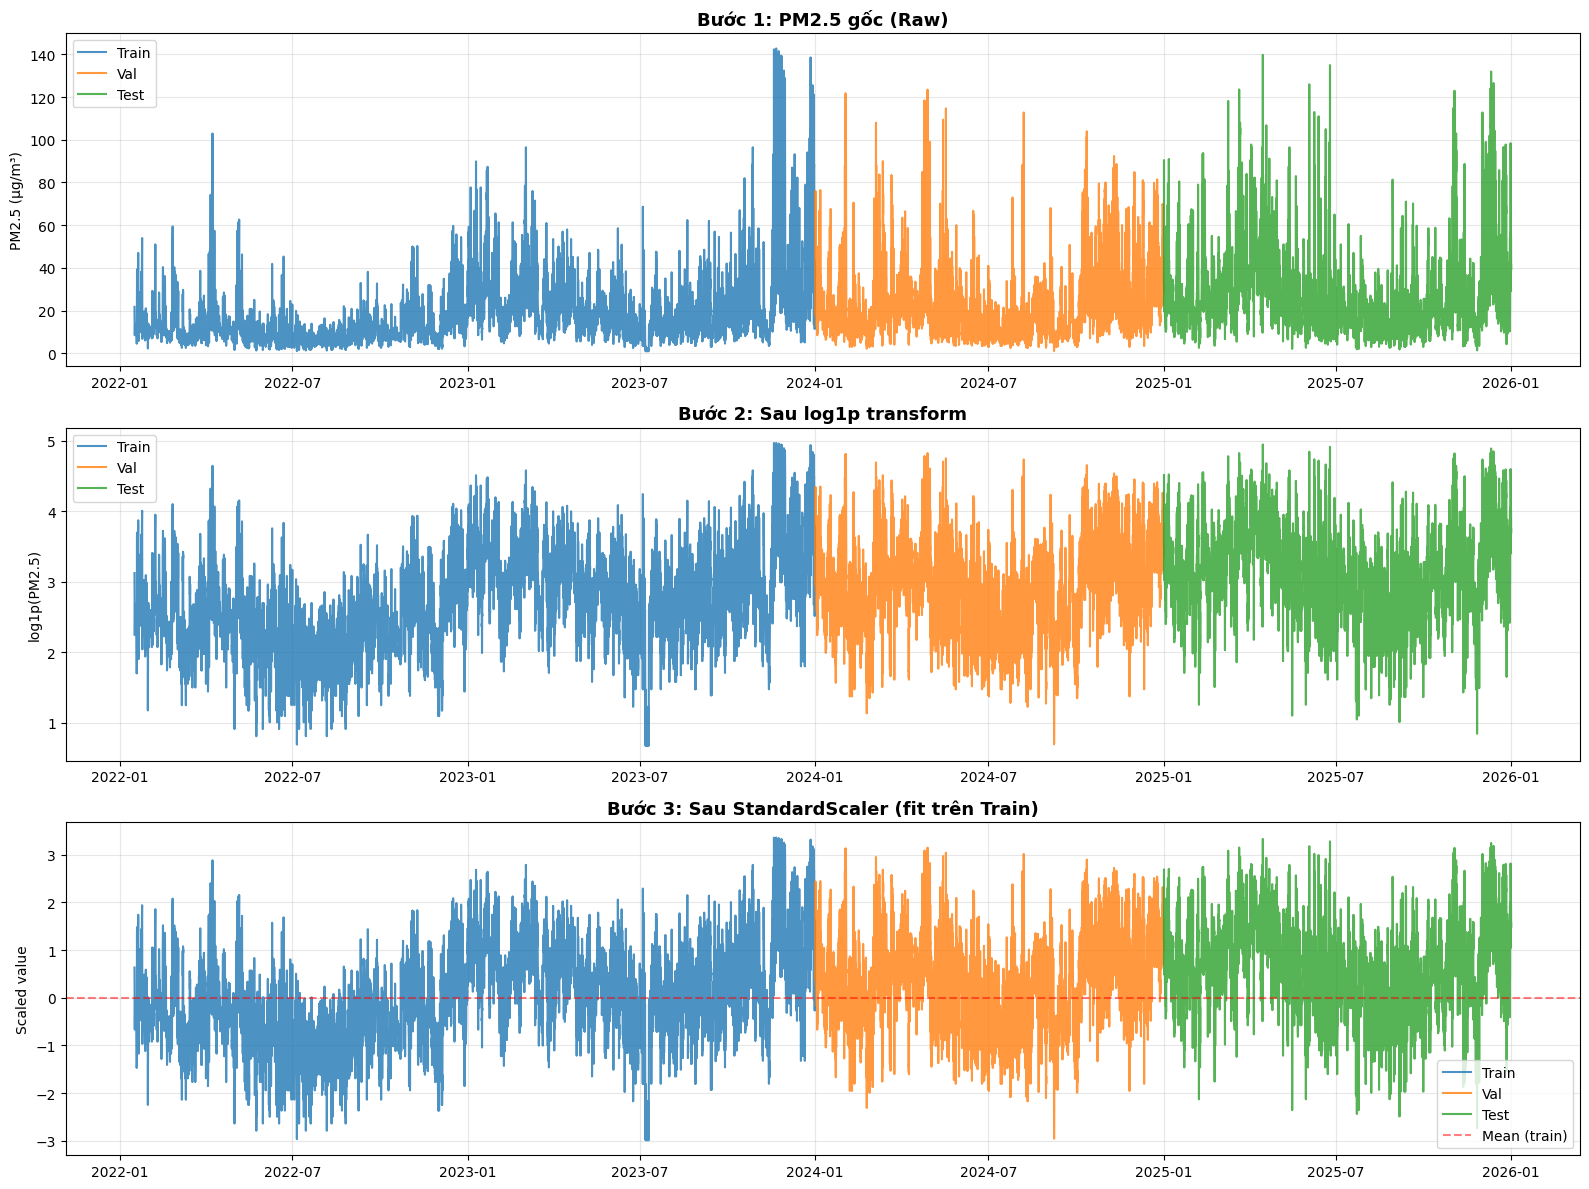

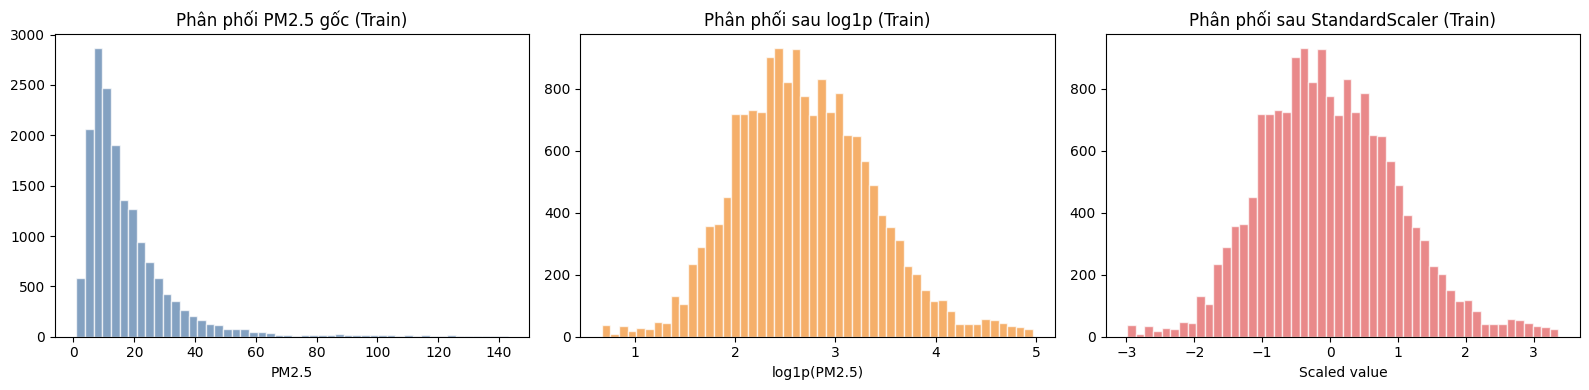

=== Thống kê qua từng bước ===
Raw      | Mean:   17.915 | Std:  16.372 | Min:    0.960 | Max: 142.800 | Skew:  3.172
Log1p    | Mean:    2.693 | Std:   0.676 | Min:    0.673 | Max:   4.968 | Skew:  0.319
Scaled   | Mean:    0.000 | Std:   1.000 | Min:   -2.987 | Max:   3.365 | Skew:  0.319


In [9]:
# Raw target
y_train_raw = train_df[[TARGET]].values
y_val_raw   = val_df[[TARGET]].values
y_test_raw  = test_df[[TARGET]].values

def forward(y):
    y = np.asarray(y, dtype=np.float64)
    return np.log1p(np.clip(y, 0, None))

y_train_t = forward(y_train_raw)
y_val_t   = forward(y_val_raw)
y_test_t  = forward(y_test_raw)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train_t)
y_val_s   = scaler_y.transform(y_val_t)
y_test_s  = scaler_y.transform(y_test_t)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

# 1) Raw
axes[0].plot(train_df.index, y_train_raw.ravel(), label='Train', alpha=0.8)
axes[0].plot(val_df.index,   y_val_raw.ravel(),   label='Val',   alpha=0.8)
axes[0].plot(test_df.index,  y_test_raw.ravel(),  label='Test',  alpha=0.8)
axes[0].set_title('Bước 1: PM2.5 gốc (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2) Log1p
axes[1].plot(train_df.index, y_train_t.ravel(), label='Train', alpha=0.8)
axes[1].plot(val_df.index,   y_val_t.ravel(),   label='Val',   alpha=0.8)
axes[1].plot(test_df.index,  y_test_t.ravel(),  label='Test',  alpha=0.8)
axes[1].set_title('Bước 2: Sau log1p transform', fontsize=13, fontweight='bold')
axes[1].set_ylabel('log1p(PM2.5)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 3) Scaled
axes[2].plot(train_df.index, y_train_s.ravel(), label='Train', alpha=0.8)
axes[2].plot(val_df.index,   y_val_s.ravel(),   label='Val',   alpha=0.8)
axes[2].plot(test_df.index,  y_test_s.ravel(),  label='Test',  alpha=0.8)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Mean (train)')
axes[2].set_title('Bước 3: Sau StandardScaler (fit trên Train)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Scaled value')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.7, color='#4e79a7', edgecolor='white')
axes[0].set_title('Phân phối PM2.5 gốc (Train)'); axes[0].set_xlabel('PM2.5')

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.7, color='#f28e2b', edgecolor='white')
axes[1].set_title('Phân phối sau log1p (Train)'); axes[1].set_xlabel('log1p(PM2.5)')

axes[2].hist(y_train_s.ravel(), bins=50, alpha=0.7, color='#e15759', edgecolor='white')
axes[2].set_title('Phân phối sau StandardScaler (Train)'); axes[2].set_xlabel('Scaled value')

plt.tight_layout()
plt.show()

print("=== Thống kê qua từng bước ===")
for name, data in [("Raw", y_train_raw), ("Log1p", y_train_t), ("Scaled", y_train_s)]:
    d = data.ravel()
    print(f"{name:8s} | Mean: {d.mean():8.3f} | Std: {d.std():7.3f} | "
          f"Min: {d.min():8.3f} | Max: {d.max():7.3f} | Skew: {pd.Series(d).skew():6.3f}")


In [10]:
print("Kích thước tập train:", train_df.shape)
print("Kích thước tập validation:", val_df.shape)
print("Kích thước tập test:", test_df.shape)

Kích thước tập train: (17154, 31)
Kích thước tập validation: (8780, 31)
Kích thước tập test: (8746, 31)


In [13]:
n_features = X_train_seq.shape[2]  
model_cnn_gru = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', 
           padding='same', input_shape=(LOOKBACK, n_features)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    GRU(256, return_sequences=True),
    Dropout(0.2),
    GRU(128,  return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Output layer cho dự đoán PM2.5
])

model_cnn_gru.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)
model_cnn_gru.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 336, 64)        │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 336, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 168, 256)       │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 168, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 168, 128)       │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,785 (1.73 MB)

 Trainable params: 454,785 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
thr = np.quantile(y_train_seq, 0.90)
w_train = np.where(y_train_seq > thr, 4.0, 1.0).astype(np.float32)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


early_stop_cnn_gru = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)
history_cnn_gru = model_cnn_gru.fit(
    X_train_seq, y_train_seq,
    sample_weight=w_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_cnn_gru, lr_scheduler],
    verbose=1
)

Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - loss: 0.3460 - mae: 0.5710 - val_loss: 0.4513 - val_mae: 0.8246 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.2394 - mae: 0.4729 - val_loss: 0.3132 - val_mae: 0.6625 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.2120 - mae: 0.4427 - val_loss: 0.2941 - val_mae: 0.6367 - learning_rate: 0.0010
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.1858 - mae: 0.4155 - val_loss: 0.3252 - val_mae: 0.6725 - learning_rate: 0.0010
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.1626 - mae: 0.3919 - val_loss: 0.3521 - val_mae: 0.7073 - learning_rate: 0.0010
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.1526 - mae: 0.3771 - val_loss: 0.3462 - val_mae: 0.7036 - learning_rate: 0.0010
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.1429 - mae: 0.3612 - val_loss: 0.4201 - val_mae: 0.7912 - learnin

In [ ]:
n_features = X_train_seq.shape[2]

model_gru = Sequential([
    tf.keras.Input(shape=(LOOKBACK, n_features)),
    GRU(256, return_sequences=True),
    Dropout(0.2),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# model_gru.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),   
    metrics=['mae']
)
model_gru.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 336, 256)       │       228,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 336, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 336, 128)       │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 336, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,681 (1.59 MB)

 Trainable params: 415,681 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:

y_pred_gru_scaled = model_cnn_gru.predict(X_test_seq)

y_pred_t = scaler_y.inverse_transform(y_pred_gru_scaled)
y_test_t_inv = scaler_y.inverse_transform(y_test_seq)

y_pred_raw = inverse_target_transform(y_pred_t)
y_test_raw_inv = inverse_target_transform(y_test_t_inv)


mae_cnn_gru  = mean_absolute_error(y_test_raw_inv, y_pred_raw)
rmse_cnn_gru = math.sqrt(mean_squared_error(y_test_raw_inv, y_pred_raw))

print(f"CNN-GRU - MAE:  {mae_cnn_gru:.4f}")
print(f"CNN-GRU - RMSE: {rmse_cnn_gru:.4f}")

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
CNN-GRU - MAE:  10.9668
CNN-GRU - RMSE: 16.0349


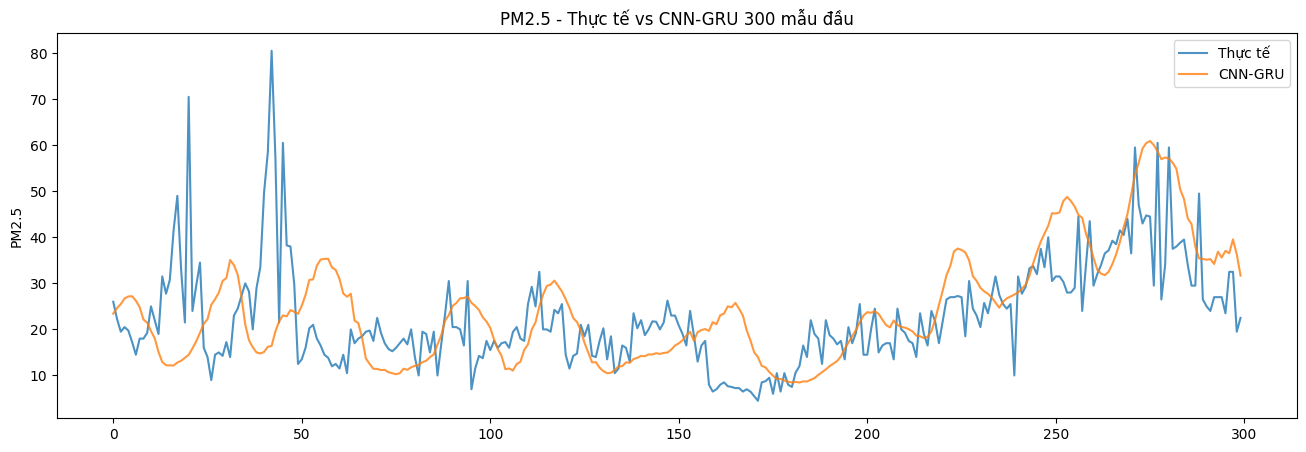

In [21]:
N = 300

plt.figure(figsize=(16, 5))
plt.plot(y_test_raw_inv[:N], label='Thực tế', alpha=0.8)
plt.plot(y_pred_raw[:N],     label='CNN-GRU', alpha=0.8)


plt.legend()
plt.title(f'PM2.5 - Thực tế vs CNN-GRU {N} mẫu đầu')
plt.ylabel('PM2.5')
plt.show()